<a href="https://colab.research.google.com/github/Steven10P/Analisis-KDM-PNC/blob/main/notebooks/04b_SVHN_PNC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade sympy

In [2]:
import sympy
import sympy.core
import torch
import torchvision

In [3]:
# ==========================================
# BLOQUE 1: MLOps, Drive, PNC y Entorno
# ==========================================
import os
import sys
import yaml
from google.colab import drive

# 1. CONEXIÓN A DRIVE Y GITHUB (Vía token seguro)
print("--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---")
drive.mount('/content/drive', force_remount=True)
CARPETA_DRIVE = '/content/drive/MyDrive/01.Maestria/MLOps'

# Aseguramos que el script de setup esté en el path
if CARPETA_DRIVE not in sys.path:
    sys.path.append(CARPETA_DRIVE)

import setup_env

# Esto lee el token y clona/actualiza el repo automáticamente
setup_env.init_project(drive_token_path=f"{CARPETA_DRIVE}/github_token.txt")

# Definimos las rutas del repo
REPO_PATH = "/content/Analisis-KDM-PNC"
if REPO_PATH not in sys.path:
    sys.path.append(REPO_PATH)

# 2. CLONAR E INYECTAR LIBRERÍA PNC (Pedro Zuidberg)
print("\n--- CLONANDO LIBRERÍA PNC ---")
%cd /content
if not os.path.exists('ProbabilisticNeuralCircuits'):
    !git clone https://github.com/pedrozudo/ProbabilisticNeuralCircuits.git

PNC_PATH = '/content/ProbabilisticNeuralCircuits'
if PNC_PATH not in sys.path:
    sys.path.append(PNC_PATH)



--- CONECTANDO A DRIVE Y CONFIGURANDO GITHUB ---
Mounted at /content/drive
🚀 Iniciando configuración del entorno MLOps...
[*] El repositorio Analisis-KDM-PNC ya existe. Haciendo 'git pull' para actualizar...
[*] Directorio de trabajo establecido en: /content/Analisis-KDM-PNC
[*] Credenciales de Git configuradas.

[✅ ÉXITO] Entorno listo. Ya puedes importar módulos de Analisis-KDM-PNC.

--- CLONANDO LIBRERÍA PNC ---
/content


In [4]:
# 3. VERIFICACIÓN DE HARDWARE (PyTorch)
print("\n--- VERIFICACIÓN DE ENTORNO ---")
print(f"PyTorch Version: {torch.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo de entrenamiento asignado: {device}")
if device.type != 'cuda':
    print("⚠️ ADVERTENCIA: No estás usando GPU. Actívala en el menú de Colab.")



--- VERIFICACIÓN DE ENTORNO ---
PyTorch Version: 2.10.0+cu128
Dispositivo de entrenamiento asignado: cuda


In [5]:
REPO_PATH

'/content/Analisis-KDM-PNC'

In [6]:
# 4. CARGAR PIPELINE DE DATOS (PyTorch)
print("\n--- PREPARANDO DATOS SVHN (Tensores) ---")
from src.data.dataset_loaders import SVHNPNCDataPipelineKFold

# <-- CAMBIO: Renombramos la variable a pipeline_svhn y usamos la carpeta data/svhn
pipeline_svhn = SVHNPNCDataPipelineKFold(batch_size=128, data_dir=f'{REPO_PATH}/data/svhn')

print(f"[✅] Muestras para K-Fold (Train+Val): {len(pipeline_svhn.train_set_full)}")
print(f"[✅] Muestras para Test final: {len(pipeline_svhn.test_set_full)}")

# Opcional pero recomendado para tu tesis: Verificar los 3 canales
sample_data, _ = next(iter(torch.utils.data.DataLoader(pipeline_svhn.train_set_full, batch_size=1)))
print(f"[🔍] Forma del Tensor SVHN: {sample_data.shape} (Debe ser [1, 3, 32, 32])")


--- PREPARANDO DATOS SVHN (Tensores) ---
Cargando datasets SVHN (Escala de Grises) para PNC...
[✅] Muestras para K-Fold (Train+Val): 73257
[✅] Muestras para Test final: 26032
[🔍] Forma del Tensor SVHN: torch.Size([1, 1, 32, 32]) (Debe ser [1, 3, 32, 32])


--- VISUALIZANDO UN LOTE DE IMÁGENES SVHN ---


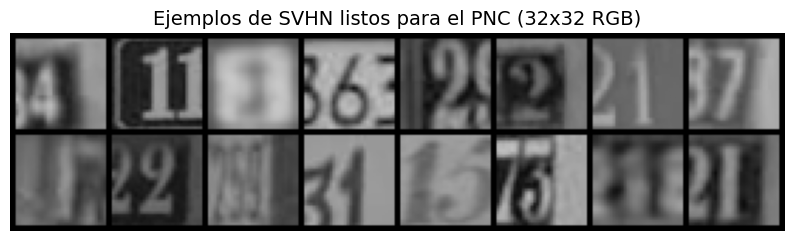

Etiquetas reales (clases):
4 1 3 6 2 2 1 7 1 2 9 1 1 3 1 1


In [7]:
# ==========================================
# BLOQUE OPCIONAL: VISUALIZACIÓN DEL DATASET SVHN
# ==========================================
import matplotlib.pyplot as plt
import numpy as np
import torchvision
import torch

print("--- VISUALIZANDO UN LOTE DE IMÁGENES SVHN ---")

# 1. Creamos un DataLoader temporal solo para sacar 16 imágenes de muestra
temp_loader = torch.utils.data.DataLoader(pipeline_svhn.train_set_full, batch_size=16, shuffle=True)

# 2. Obtenemos el primer lote (batch) de imágenes y etiquetas
imagenes, etiquetas = next(iter(temp_loader))

# 3. Función auxiliar para mostrar las imágenes de PyTorch
def imshow(img):
    # img actual: [3, Alto, Ancho]
    npimg = img.numpy()

    # Matplotlib necesita: [Alto, Ancho, 3 canales RGB]
    # Usamos transpose para mover el eje 0 (canales) a la posición 2
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

# 4. Graficamos usando un grid de torchvision
plt.figure(figsize=(10, 4))
imshow(torchvision.utils.make_grid(imagenes, nrow=8))
plt.title("Ejemplos de SVHN listos para el PNC (32x32 RGB)", fontsize=14)
plt.show()

# 5. Imprimimos las etiquetas reales que PyTorch extrajo
print("Etiquetas reales (clases):")
print(" ".join(f'{etiquetas[j].item()}' for j in range(16)))

In [8]:
# 5. CARGAR CONFIGURACIÓN DESDE YAML
with open(f"{REPO_PATH}/configs/svhn/pnc.yaml", 'r') as file:
    config_pnc_svhn = yaml.safe_load(file)

print("\n[INFO] Parámetros base cargados:", config_pnc_svhn['fixed_params'])
print("[INFO] Espacio de búsqueda cargado:", config_pnc_svhn['grid_search'])


[INFO] Parámetros base cargados: {'height': 32, 'width': 32, 'channels': 3, 'n_classes': 10, 'mixing': 'sum', 'batch_size': 128, 'optimizer': 'adam'}
[INFO] Espacio de búsqueda cargado: {'components': [5, 10, 20], 'lr': [0.001, 0.005]}


In [10]:
# ==========================================
# BLOQUE 2: ENTRENAMIENTO PNC (SVHN) Y TRAZABILIDAD
# ==========================================
import itertools
import time
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
import yaml
import os
import torch

# 1. Rutas de persistencia MLOps para SVHN
ruta_base = os.path.join(REPO_PATH, "resultados/svhn")
os.makedirs(f"{ruta_base}/metricas", exist_ok=True)
os.makedirs(f"{ruta_base}/modelos", exist_ok=True)

ruta_historial_csv = f"{ruta_base}/metricas/pnc_svhn_kfold_history.csv"
ruta_mejor_modelo_pnc = f"{ruta_base}/modelos/mejor_pnc_svhn.pth"
ruta_mejores_params = f"{ruta_base}/metricas/best_pnc_svhn_params.yaml"

# 2. Lógica Fast-Track MLOps
if os.path.exists(ruta_mejores_params) and os.path.exists(ruta_mejor_modelo_pnc):
    print(f"[⏩] Búsqueda ya realizada. Mejor modelo en: {ruta_mejor_modelo_pnc}")
    print("Saltando el entrenamiento...")
else:
    print("\n--- INICIANDO ENTRENAMIENTO PNC SVHN (GRID SEARCH + K-FOLD) ---")

    EPOCHS = 5
    K_FOLDS = 3
    kf = KFold(n_splits=K_FOLDS, shuffle=True, random_state=42)

    # Configuración de SVHN
    params_grid = config_pnc_svhn['grid_search']
    keys, values = zip(*params_grid.items())
    grid_configs = [dict(zip(keys, v)) for v in itertools.product(*values)]
    print(f"Total arquitecturas PNC a evaluar en SVHN: {len(grid_configs)}")

    historial_global_pnc = []
    mejor_accuracy_global_pnc = 0.0
    mejor_config_global_pnc = None

    for idx_config, conf in enumerate(grid_configs):
        # Unimos parámetros fijos (32x32) con los del grid
        conf_completa = {**config_pnc_svhn['fixed_params'], **conf}

        print(f"\n[{idx_config+1}/{len(grid_configs)}] Config: Components={conf['components']}, LR={conf['lr']}, Momentum={conf.get('momentum', 'N/A')}")

        # Submuestreo para agilizar el Grid Search en SVHN (33% del dataset)
        TOTAL_MUESTRAS = len(pipeline_svhn.train_set_full)
        idx_sample_global = np.random.choice(TOTAL_MUESTRAS, int(TOTAL_MUESTRAS * 0.33), replace=False)

        for fold, (train_rel_idx, val_rel_idx) in enumerate(kf.split(idx_sample_global)):
            train_idx = idx_sample_global[train_rel_idx]
            val_idx = idx_sample_global[val_rel_idx]

            train_loader, val_loader = pipeline_svhn.get_fold_loaders(train_idx, val_idx)

            # Importamos desde factory_v2 como solicitaste
            from src.models.pnc_factory_v2 import build_pnc_model
            modelo_pnc, optimizer_pnc, criterion, total_params = build_pnc_model(conf_completa, device)

            for epoch in range(EPOCHS):
                epoch_time_start = time.time()

                # --- FASE DE ENTRENAMIENTO ---
                modelo_pnc.train()
                train_loss, train_correct, train_total = 0.0, 0, 0
                for data, target in train_loader:
                    # [CAMBIO CORRECTO]: Usamos .squeeze(1) porque el pipeline de SVHN es 1 canal (Grayscale)
                    # Esto convierte [B, 1, 32, 32] -> [B, 32, 32]
                    data = data.squeeze(1).to(device)
                    data = (data * 255.0).long().float()
                    target = target.to(device)

                    optimizer_pnc.zero_grad()
                    log_probs = modelo_pnc(data)
                    loss = criterion(log_probs, target)
                    loss.backward()
                    optimizer_pnc.step()

                    train_loss += loss.item() * data.size(0)
                    _, predicted = log_probs.max(1)
                    train_total += target.size(0)
                    train_correct += predicted.eq(target).sum().item()

                # --- FASE DE VALIDACIÓN ---
                modelo_pnc.eval()
                val_loss, val_correct, val_total = 0.0, 0, 0
                with torch.no_grad():
                    for data, target in val_loader:
                        # [CAMBIO CORRECTO]: squeeze(1) también en validación
                        data = data.squeeze(1).to(device)
                        data = (data * 255.0).long().float()
                        target = target.to(device)

                        log_probs = modelo_pnc(data)
                        loss = criterion(log_probs, target)

                        val_loss += loss.item() * data.size(0)
                        _, predicted = log_probs.max(1)
                        val_total += target.size(0)
                        val_correct += predicted.eq(target).sum().item()

                # --- REGISTRO MLOps ---
                epoch_time = time.time() - epoch_time_start
                val_acc = val_correct / val_total

                registro_epoca = {
                    'config_id': idx_config + 1, 'components': conf['components'],
                    'lr': conf['lr'], 'momentum': conf.get('momentum', 'N/A'),
                    'fold': fold + 1, 'epoch': epoch + 1,
                    'train_loss': train_loss / train_total, 'train_acc': train_correct / train_total,
                    'val_loss': val_loss / val_total, 'val_acc': val_acc,
                    'epoch_time_seconds': epoch_time, 'total_params': total_params
                }
                historial_global_pnc.append(registro_epoca)

                if val_acc > mejor_accuracy_global_pnc:
                    mejor_accuracy_global_pnc = val_acc
                    mejor_config_global_pnc = conf
                    torch.save(modelo_pnc.state_dict(), ruta_mejor_modelo_pnc)

            print(f"    Fin Fold {fold+1} | Val Acc: {val_acc:.4f} | Tiempo: ~{epoch_time:.1f}s")

    # Guardar resultados
    pd.DataFrame(historial_global_pnc).to_csv(ruta_historial_csv, index=False)
    with open(ruta_mejores_params, 'w') as file:
        yaml.dump(mejor_config_global_pnc, file)

    print(f"\n[🏆] Búsqueda finalizada. Mejor Val Acc SVHN: {mejor_accuracy_global_pnc:.4f}")
    print(f"[✅] Modelo y métricas guardados en: {ruta_base}")


--- INICIANDO ENTRENAMIENTO PNC SVHN (GRID SEARCH + K-FOLD) ---
Total arquitecturas PNC a evaluar en SVHN: 6

[1/6] Config: Components=5, LR=0.001, Momentum=N/A
    Fin Fold 1 | Val Acc: 0.2288 | Tiempo: ~9.7s
    Fin Fold 2 | Val Acc: 0.1912 | Tiempo: ~9.1s
    Fin Fold 3 | Val Acc: 0.2224 | Tiempo: ~9.7s

[2/6] Config: Components=5, LR=0.005, Momentum=N/A
    Fin Fold 1 | Val Acc: 0.2014 | Tiempo: ~9.4s
    Fin Fold 2 | Val Acc: 0.2015 | Tiempo: ~9.7s
    Fin Fold 3 | Val Acc: 0.2328 | Tiempo: ~9.3s

[3/6] Config: Components=10, LR=0.001, Momentum=N/A
    Fin Fold 1 | Val Acc: 0.2053 | Tiempo: ~24.1s
    Fin Fold 2 | Val Acc: 0.2015 | Tiempo: ~24.2s
    Fin Fold 3 | Val Acc: 0.2081 | Tiempo: ~24.0s

[4/6] Config: Components=10, LR=0.005, Momentum=N/A
    Fin Fold 1 | Val Acc: 0.1952 | Tiempo: ~24.0s
    Fin Fold 2 | Val Acc: 0.2282 | Tiempo: ~24.2s
    Fin Fold 3 | Val Acc: 0.2270 | Tiempo: ~24.1s

[5/6] Config: Components=20, LR=0.001, Momentum=N/A
    Fin Fold 1 | Val Acc: 0.2000 

In [11]:
1

1

In [15]:
# ==========================================
# BLOQUE 3: ENTRENAMIENTO FINAL Y CURVAS (SVHN-PNC)
# ==========================================
import yaml
import time
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import DataLoader
import os

# 1. Rutas de artefactos finales (Apuntando a svhn)
os.makedirs(f"{REPO_PATH}/resultados/svhn/graficas", exist_ok=True) # <-- Seguro para evitar error de carpeta inexistente

ruta_mejores_params = f"{REPO_PATH}/resultados/svhn/metricas/best_pnc_svhn_params.yaml"
ruta_modelo_campeon = f"{REPO_PATH}/resultados/svhn/modelos/pnc_svhn_best_model.pth"
ruta_matriz_conf = f"{REPO_PATH}/resultados/svhn/graficas/pnc_svhn_confusion_matrix.png"
ruta_reporte_test = f"{REPO_PATH}/resultados/svhn/metricas/pnc_svhn_test_report.csv"
ruta_curvas_entrenamiento = f"{REPO_PATH}/resultados/svhn/graficas/pnc_svhn_training_curves.png"

# 2. Cargar la configuración ganadora
if not os.path.exists(ruta_mejores_params):
    raise FileNotFoundError("¡No se encontró el archivo de mejores parámetros! Ejecuta el Bloque 2 primero.")

with open(ruta_mejores_params, 'r') as file:
    best_params = yaml.safe_load(file)

print("\n--- INICIANDO ENTRENAMIENTO DEL CAMPEÓN PNC (SVHN) ---")
print(f"Parámetros óptimos a utilizar: {best_params}")

# Usar config_pnc_svhn
conf_completa = {**config_pnc_svhn['fixed_params'], **best_params}

# 3. Preparar DataLoaders (Usando pipeline_svhn de forma directa y segura)
train_loader_full = DataLoader(pipeline_svhn.train_set_full, batch_size=conf_completa['batch_size'], shuffle=True)
test_loader = DataLoader(pipeline_svhn.test_set_full, batch_size=conf_completa['batch_size'], shuffle=False)

# 4. Instanciar el modelo definitivo
from src.models.pnc_factory_v2 import build_pnc_model
modelo_final, optimizer, criterion, total_params = build_pnc_model(conf_completa, device)

# 5. Bucle de Entrenamiento Final (con historial)
EPOCHS_FINAL = 10
print(f"Entrenando sobre {len(pipeline_svhn.train_set_full)} muestras por {EPOCHS_FINAL} épocas...")

# Listas para guardar la evolución
historial_train_loss, historial_train_acc = [], []
historial_test_loss, historial_test_acc = [], []

tiempo_inicio_total = time.time()
for epoch in range(EPOCHS_FINAL):
    epoch_time_start = time.time()

# --- FASE DE TRAIN ---
    modelo_final.train()
    train_loss, train_correct, train_total = 0.0, 0, 0  # <--- ¡CORREGIDO AQUÍ!

    for data, target in train_loader_full:
        # [MANTENEMOS]: .squeeze(1) para convertir [B, 1, 32, 32] a [B, 32, 32]
        data = data.squeeze(1).to(device)
        data = (data * 255.0).long().float()
        target = target.to(device)

        optimizer.zero_grad()
        log_probs = modelo_final(data)
        loss = criterion(log_probs, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * data.size(0)
        _, predicted = log_probs.max(1)
        train_total += target.size(0)
        train_correct += predicted.eq(target).sum().item()

    epoch_train_loss = train_loss / train_total
    epoch_train_acc = train_correct / train_total
    historial_train_loss.append(epoch_train_loss)
    historial_train_acc.append(epoch_train_acc)

    # --- FASE DE EVALUACIÓN (TEST) POR ÉPOCA ---
    modelo_final.eval()
    test_loss, test_correct, test_total = 0.0, 0, 0
    with torch.no_grad():
        for data, target in test_loader:
            # [MANTENEMOS]: .squeeze(1) también en evaluación
            data = data.squeeze(1).to(device)
            data = (data * 255.0).long().float()
            target = target.to(device)

            log_probs = modelo_final(data)
            loss = criterion(log_probs, target)

            test_loss += loss.item() * data.size(0)
            _, predicted = log_probs.max(1)
            test_total += target.size(0)
            test_correct += predicted.eq(target).sum().item()

    epoch_test_loss = test_loss / test_total
    epoch_test_acc = test_correct / test_total
    historial_test_loss.append(epoch_test_loss)
    historial_test_acc.append(epoch_test_acc)

    epoch_time = time.time() - epoch_time_start
    print(f"  Época [{epoch+1:02d}/{EPOCHS_FINAL}] | Train Acc: {epoch_train_acc:.4f} - Val Acc: {epoch_test_acc:.4f} | Tiempo: {epoch_time:.1f}s")

tiempo_total_entrenamiento = time.time() - tiempo_inicio_total
print(f"\n[✅] Entrenamiento completado en {tiempo_total_entrenamiento/60:.1f} minutos.")

# 6. Guardar pesos del modelo campeón
torch.save(modelo_final.state_dict(), ruta_modelo_campeon)
print(f"[✅] Modelo campeón guardado en: {ruta_modelo_campeon}")


--- INICIANDO ENTRENAMIENTO DEL CAMPEÓN PNC (SVHN) ---
Parámetros óptimos a utilizar: {'components': 5, 'lr': 0.005}
Entrenando sobre 73257 muestras por 10 épocas...
  Época [01/10] | Train Acc: 0.1943 - Val Acc: 0.1945 | Tiempo: 40.9s
  Época [02/10] | Train Acc: 0.2189 - Val Acc: 0.1827 | Tiempo: 41.7s
  Época [03/10] | Train Acc: 0.2255 - Val Acc: 0.1830 | Tiempo: 40.4s
  Época [04/10] | Train Acc: 0.2322 - Val Acc: 0.2234 | Tiempo: 40.5s
  Época [05/10] | Train Acc: 0.2363 - Val Acc: 0.1974 | Tiempo: 40.4s
  Época [06/10] | Train Acc: 0.2429 - Val Acc: 0.2166 | Tiempo: 40.3s
  Época [07/10] | Train Acc: 0.2457 - Val Acc: 0.2173 | Tiempo: 40.5s
  Época [08/10] | Train Acc: 0.2510 - Val Acc: 0.2235 | Tiempo: 40.2s
  Época [09/10] | Train Acc: 0.2576 - Val Acc: 0.2468 | Tiempo: 40.1s
  Época [10/10] | Train Acc: 0.2566 - Val Acc: 0.2563 | Tiempo: 40.2s

[✅] Entrenamiento completado en 6.8 minutos.
[✅] Modelo campeón guardado en: /content/Analisis-KDM-PNC/resultados/svhn/modelos/pnc_s


--- GENERANDO GRÁFICAS DE ENTRENAMIENTO (SVHN) ---


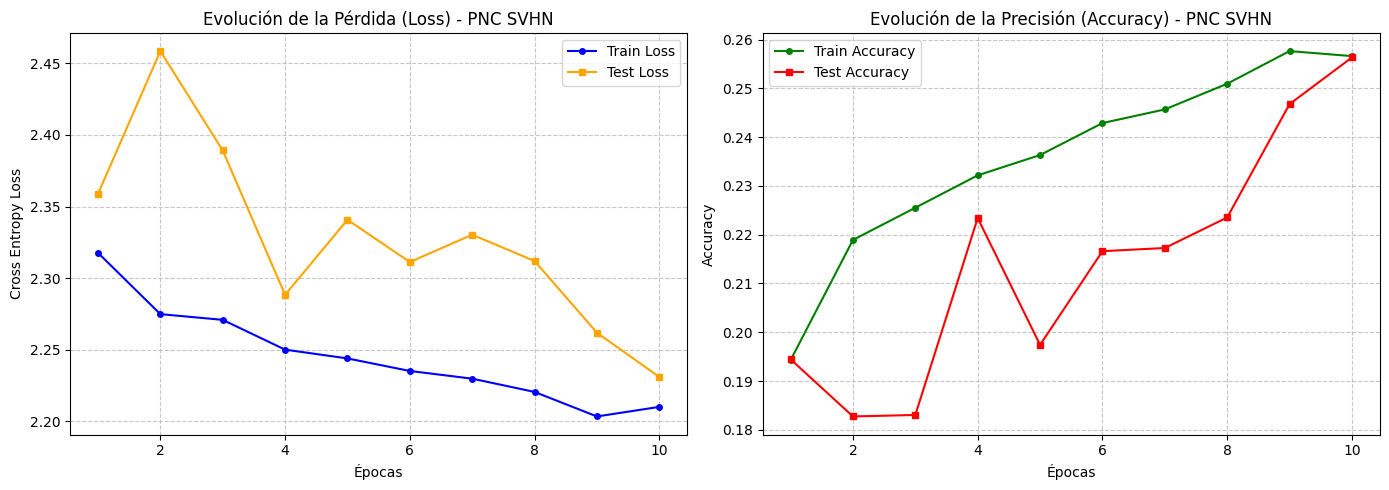

[✅] Gráficas de entrenamiento guardadas en: /content/Analisis-KDM-PNC/resultados/svhn/graficas/pnc_svhn_training_curves.png

--- GENERANDO MATRIZ DE CONFUSIÓN FINAL (SVHN) ---
[🏆] ACCURACY FINAL EN TEST (PNC SVHN): 0.2563


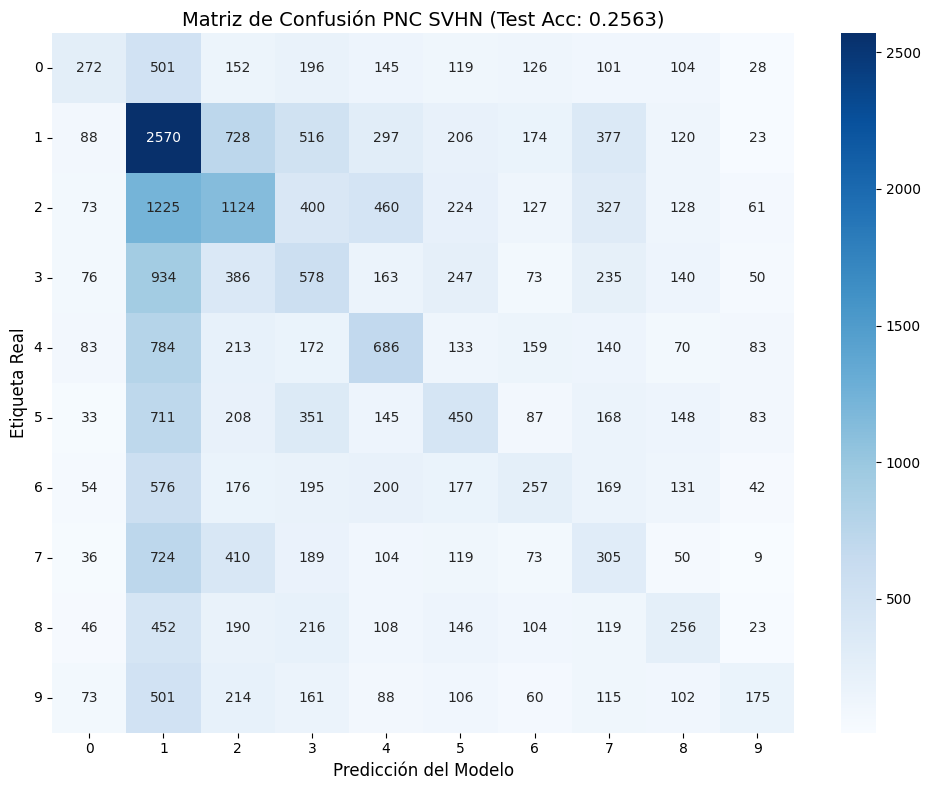

[✅] Matriz de confusión guardada en: /content/Analisis-KDM-PNC/resultados/svhn/graficas/pnc_svhn_confusion_matrix.png


In [16]:
import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# [CAMBIO CRÍTICO]: Las clases de SVHN son los dígitos del 0 al 9
class_names = [str(i) for i in range(10)]

# ==========================================
# 7. GRÁFICAS DE EVOLUCIÓN (ACCURACY Y LOSS)
# ==========================================
print("\n--- GENERANDO GRÁFICAS DE ENTRENAMIENTO (SVHN) ---")

# SEGURIDAD MLOps: Asegurar que el directorio de métricas existe
os.makedirs(os.path.dirname(ruta_curvas_entrenamiento), exist_ok=True)

# Crear la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de Loss
ax1.plot(range(1, EPOCHS_FINAL + 1), historial_train_loss, label='Train Loss', color='blue', marker='o', markersize=4)
ax1.plot(range(1, EPOCHS_FINAL + 1), historial_test_loss, label='Test Loss', color='orange', marker='s', markersize=4)
ax1.set_title('Evolución de la Pérdida (Loss) - PNC SVHN')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Cross Entropy Loss')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Gráfica de Accuracy
ax2.plot(range(1, EPOCHS_FINAL + 1), historial_train_acc, label='Train Accuracy', color='green', marker='o', markersize=4)
ax2.plot(range(1, EPOCHS_FINAL + 1), historial_test_acc, label='Test Accuracy', color='red', marker='s', markersize=4)
ax2.set_title('Evolución de la Precisión (Accuracy) - PNC SVHN')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()

# CRÍTICO: Guardar ANTES de mostrar
plt.savefig(ruta_curvas_entrenamiento, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig) # Liberar memoria

print(f"[✅] Gráficas de entrenamiento guardadas en: {ruta_curvas_entrenamiento}")

# ==========================================
# 8. MATRIZ DE CONFUSIÓN Y REPORTE FINAL
# ==========================================
print("\n--- GENERANDO MATRIZ DE CONFUSIÓN FINAL (SVHN) ---")

# Re-asegurar directorio
os.makedirs(os.path.dirname(ruta_matriz_conf), exist_ok=True)

all_preds = []
all_targets = []
modelo_final.eval()

with torch.no_grad():
    for data, target in test_loader:
        # [MANTENEMOS]: El squeeze(1) gracias a nuestra técnica de escala de grises
        data = data.squeeze(1).to(device)
        data = (data * 255.0).long().float()
        target = target.to(device)

        log_probs = modelo_final(data)
        _, predicted = log_probs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_targets.extend(target.cpu().numpy())

test_acc_final = historial_test_acc[-1]
print(f"[🏆] ACCURACY FINAL EN TEST (PNC SVHN): {test_acc_final:.4f}")

cm = confusion_matrix(all_targets, all_preds)

# REPORTE CSV CON ETIQUETAS DE DÍGITOS
reporte = classification_report(all_targets, all_preds, target_names=class_names, output_dict=True)
pd.DataFrame(reporte).transpose().to_csv(ruta_reporte_test)

# GRAFICAR MATRIZ CON COLOR AZUL (Diferenciación visual para la tesis)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matriz de Confusión PNC SVHN (Test Acc: {test_acc_final:.4f})', fontsize=14)
plt.ylabel('Etiqueta Real', fontsize=12)
plt.xlabel('Predicción del Modelo', fontsize=12)

# Rotar los textos de los ejes
plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()

# CRÍTICO: Guardar ANTES de mostrar
plt.savefig(ruta_matriz_conf, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f"[✅] Matriz de confusión guardada en: {ruta_matriz_conf}")

In [17]:
# ==========================================
# BLOQUE 4: MLOps - GUARDAR EN GITHUB (PNC SVHN)
# ==========================================
import os

print("\n--- INICIANDO BACKUP A GITHUB ---")
%cd {REPO_PATH}

# 1. Configurar identidad de Git (Colab)
!git config --global user.email "bspenad@gmail.com"
!git config --global user.name "bspenad (Google Colab)"

# [CAMBIO CRÍTICO MLOps]: Sincronizar el repo remoto ANTES de hacer push.
# Esto previene el error fatal de "Updates were rejected"
print("\n[INFO] Sincronizando repositorio local con GitHub...")
!git config pull.rebase false  # Configuración para evitar conflictos de merge
!git pull origin main

# 2. Mostrar qué archivos han cambiado o son nuevos
print("\n[INFO] Archivos modificados/creados:")
!git status -s

# 3. Agregar todos los cambios (Modelos .pth, CSVs, Gráficas azules, Notebook)
!git add .

# 4. Hacer el Commit (CAMBIO: Mensaje específico para SVHN)
MENSAJE_COMMIT = "feat(PNC-SVHN): Entrenamiento campeón, curvas, métricas y matriz de confusión azul"
!git commit -m "{MENSAJE_COMMIT}"

# 5. Hacer el Push a la rama principal (main)
print("\n[INFO] Subiendo archivos al repositorio...")
!git push origin main

print("\n[✅] ¡Todo guardado exitosamente en GitHub!")
%cd /content


--- INICIANDO BACKUP A GITHUB ---
/content/Analisis-KDM-PNC

[INFO] Sincronizando repositorio local con GitHub...
remote: Enumerating objects: 6, done.
remote: Counting objects: 100% (6/6), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 4 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 78.78 KiB | 1.04 MiB/s, done.
From https://github.com/Steven10P/Analisis-KDM-PNC
 * branch            main       -> FETCH_HEAD
   96e0047..ae6bc8e  main       -> origin/main
Updating 96e0047..ae6bc8e
Fast-forward
 notebooks/04a_SVHN_KDM.ipynb | 1003 ++++++++++++++++++++++++++++++++++++++++++
 1 file changed, 1003 insertions(+)
 create mode 100644 notebooks/04a_SVHN_KDM.ipynb

[INFO] Archivos modificados/creados:
?? resultados/svhn/graficas/pnc_svhn_confusion_matrix.png
?? resultados/svhn/graficas/pnc_svhn_training_curves.png
?? resultados/svhn/metricas/best_pnc_svhn_params.yaml
?? resultados/svhn/metricas/pnc_svhn_kfold_history.csv
?? resultados/s